## Data description

link: https://docs.google.com/document/d/1X2GbykWLQlnttuWn8yi8y_jkvNyixsIJT8VYAbNi_2c/edit?usp=sharing


###  CSV Data Summary (saved fields, units, physical meaning)

| CSV File | Column | Unit | Physical Meaning |
|---|---|---|---|
| `PointCloud_snr.csv` | `timestamp_s` | s | Time from start of capture/frame timeline |
| `PointCloud_snr.csv` | `frame_number` | index | Radar frame ID |
| `PointCloud_snr.csv` | `point_index` | index | Detection ID inside a frame |
| `PointCloud_snr.csv` | `x` | m | Lateral coordinate in sensor Cartesian frame |
| `PointCloud_snr.csv` | `y` | m | Forward/depth coordinate from sensor |
| `PointCloud_snr.csv` | `z` | m | Vertical coordinate (height) |
| `PointCloud_snr.csv` | `doppler` | m/s | Radial velocity of detection (sign indicates direction) |
| `PointCloud_snr.csv` | `range` | m | Radial distance from sensor |
| `PointCloud_snr.csv` | `aoa` | degree | Estimated angle of arrival |
| `PointCloud_snr.csv` | `snr` | dB | Signal-to-noise ratio of detection |
| `PointCloud_snr.csv` | `noise` | dB (sensor scale) | Background noise estimate near detection |
| `range_doppler.csv` | `timestamp_s` | s | Time of frame |
| `range_doppler.csv` | `frame_number` | index | Radar frame ID |
| `range_doppler.csv` | `range_bin` | bin index | Discrete distance-bin location in FFT grid |
| `range_doppler.csv` | `doppler_bin` | bin index | Discrete velocity-bin location in FFT grid |
| `range_doppler.csv` | `signal_strength` | power/counts (arb.) | Return energy/intensity at (`range_bin`, `doppler_bin`) |


In [8]:
from pathlib import Path
import pandas as pd


def first_existing_dir(parent: Path, names):
    for name in names:
        p = parent / name
        if p.exists() and p.is_dir():
            return p
    return None


def first_existing_file(parent: Path, names):
    for name in names:
        p = parent / name
        if p.exists() and p.is_file():
            return p
    return None


def find_root(start: Path) -> Path:
    markers = ["Single Activity", "Single Activity Data", "Multipersonal Activity", "Multi personal activity"]
    for base in [start, *start.parents]:
        if any((base / m).exists() for m in markers):
            return base
    return start


def session_summary_table(dataset_root: Path, dataset_label: str) -> pd.DataFrame:
    data_root = first_existing_dir(dataset_root, ["3D data", "3D", "3d data", "3d"])
    if data_root is None:
        return pd.DataFrame(columns=["activity", "sample", "range_doppler_shape", "pointcloud_shape", "n_frames"])

    rows = []
    for activity_dir in sorted([d for d in data_root.iterdir() if d.is_dir()]):
        for sample_dir in sorted([d for d in activity_dir.iterdir() if d.is_dir()]):
            rd_path = sample_dir / "range_doppler.csv"
            pc_path = first_existing_file(sample_dir, ["PointCloud_snr.csv", "point_cloud_snr.csv", "points_cloud_snr.csv"])

            rd_shape = "missing"
            pc_shape = "missing"
            n_frames = 0

            if rd_path.exists():
                rd_df = pd.read_csv(rd_path)
                rd_shape = f"{rd_df.shape[0]} x {rd_df.shape[1]}"
                if "frame_number" in rd_df.columns:
                    n_frames = int(pd.to_numeric(rd_df["frame_number"], errors="coerce").dropna().astype(int).nunique())
                else:
                    n_frames = int(len(rd_df))

            if pc_path is not None:
                pc_df = pd.read_csv(pc_path)
                pc_shape = f"{pc_df.shape[0]} x {pc_df.shape[1]}"

            rows.append({
                "activity": activity_dir.name,
                "sample": sample_dir.name,
                "range_doppler_shape": rd_shape,
                "pointcloud_shape": pc_shape,
                "n_frames": n_frames,
            })

    out = pd.DataFrame(rows).sort_values(["activity", "sample"]).reset_index(drop=True)
    print(f"{dataset_label}: {len(out)} sessions")
    return out


research_root = find_root(Path.cwd())
single_root = first_existing_dir(research_root, ["Single Activity", "Single Activity Data"])
multi_root = first_existing_dir(research_root, ["Multipersonal Activity", "Multi personal activity", "Multi-personal Activity"])

if single_root is None:
    raise FileNotFoundError("Single Activity folder not found")
if multi_root is None:
    raise FileNotFoundError("Multipersonal Activity folder not found")

single_summary_table = session_summary_table(single_root, "Single Activity")
multi_summary_table = session_summary_table(multi_root, "Multipersonal Activity")

print("\nSingle Activity Summary")
display(single_summary_table)

print("Multipersonal Activity Summary")
display(multi_summary_table)

Single Activity: 20 sessions
Multipersonal Activity: 25 sessions

Single Activity Summary


,activity,sample,range_doppler_shape,pointcloud_shape,n_frames
0,Sitting,1 m,1196032 x 5,401 x 11,146
1,Sitting,2 m,1089536 x 5,292 x 11,133
2,Sitting,3 m,1024000 x 5,151 x 11,125
3,Sitting,4 m,1122304 x 5,152 x 11,137
4,Sitting,5 m,1146880 x 5,159 x 11,140
5,Standing,1 m,1155072 x 5,301 x 11,141
6,Standing,2 m,1163264 x 5,316 x 11,142
7,Standing,3 m,1146880 x 5,201 x 11,140
8,Standing,4 m,1097728 x 5,181 x 11,134
9,Standing,5 m,1318912 x 5,193 x 11,161


Multipersonal Activity Summary


,activity,sample,range_doppler_shape,pointcloud_shape,n_frames
0,Approaching,1 m,827392 x 5,663 x 11,101
1,Approaching,2 m,892928 x 5,632 x 11,109
2,Approaching,2.5 m,745472 x 5,631 x 11,91
3,Approaching,3 m,720896 x 5,614 x 11,88
4,Approaching,4 m,860160 x 5,700 x 11,105
5,Sitting,1 m,1187840 x 5,650 x 11,145
6,Sitting,2 m,1286144 x 5,785 x 11,157
7,Sitting,2.5 m,1359872 x 5,881 x 11,166
8,Sitting,3 m,1449984 x 5,1047 x 11,177
9,Sitting,4 m,1220608 x 5,879 x 11,149


### Plotting Angle of Arrival AoA


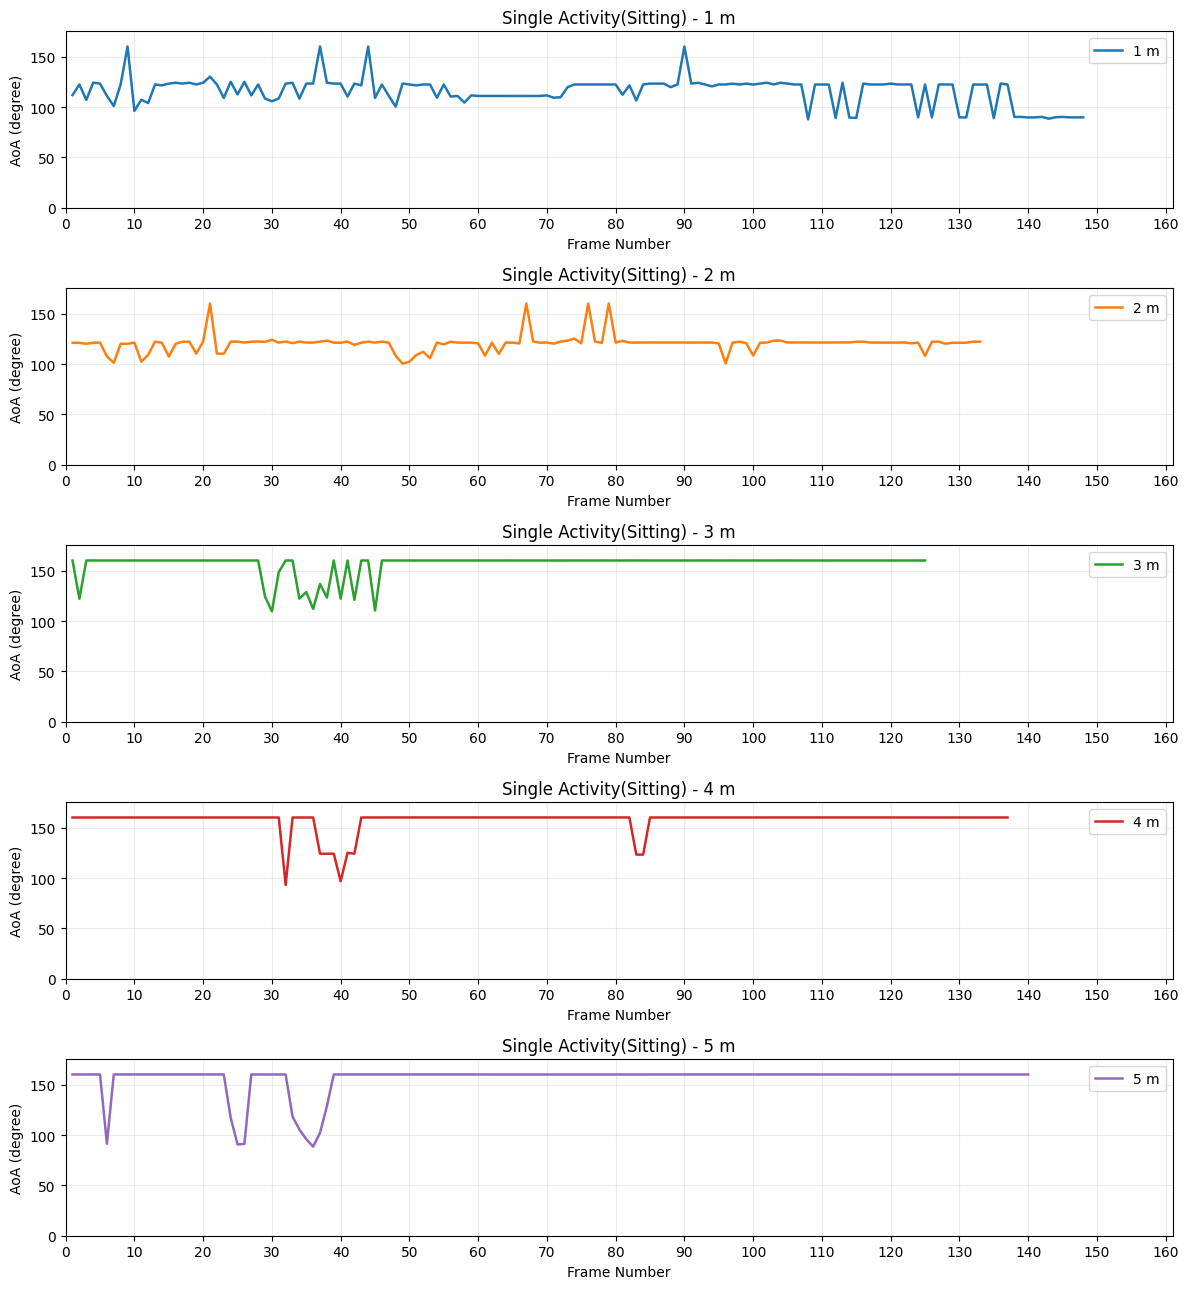

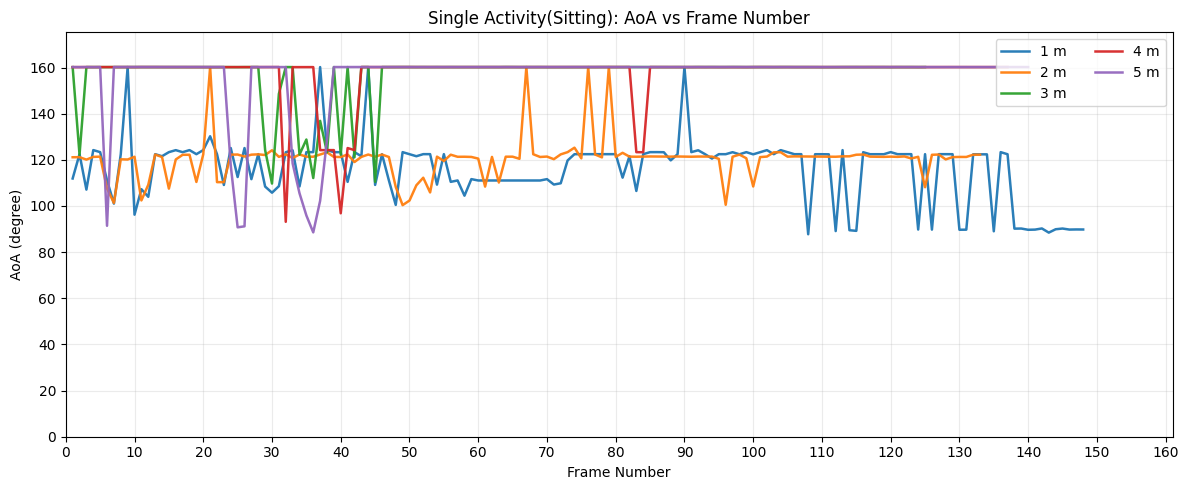

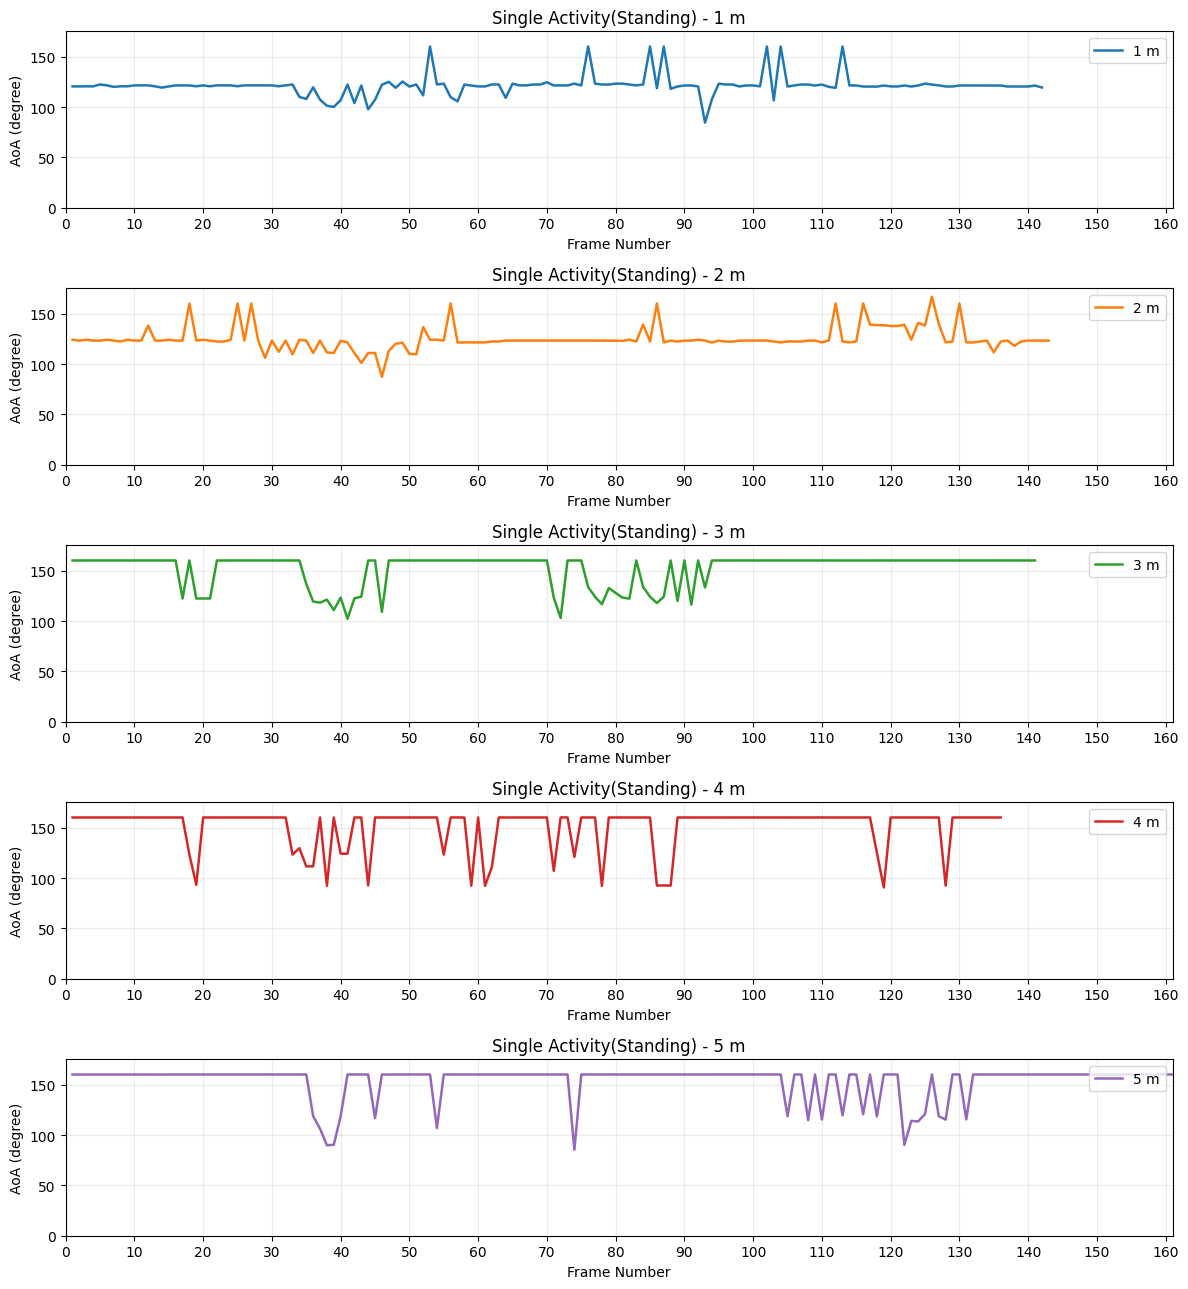

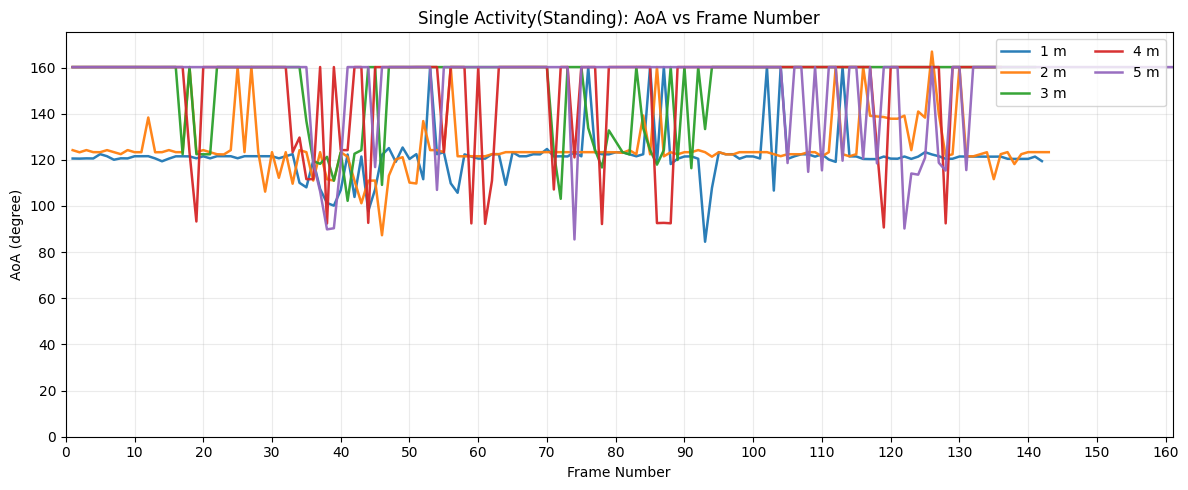

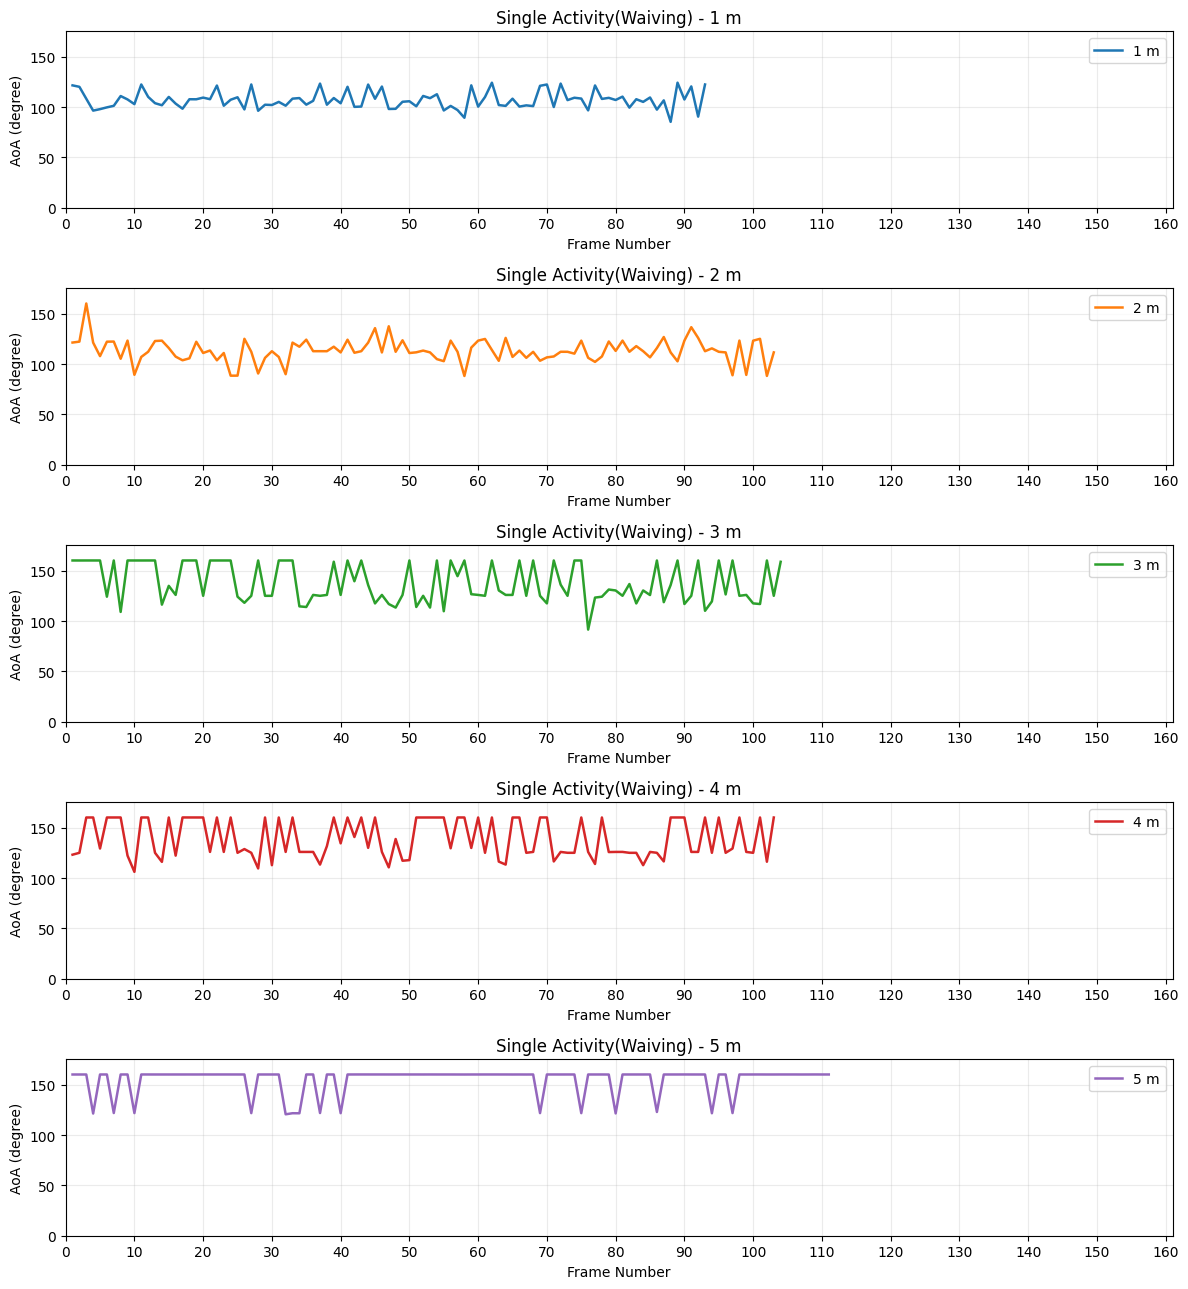

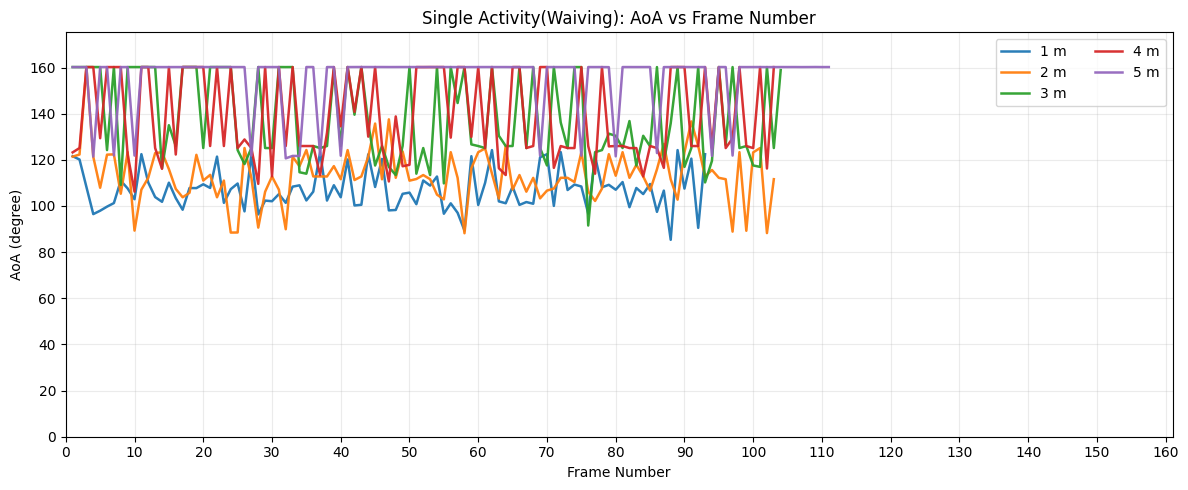

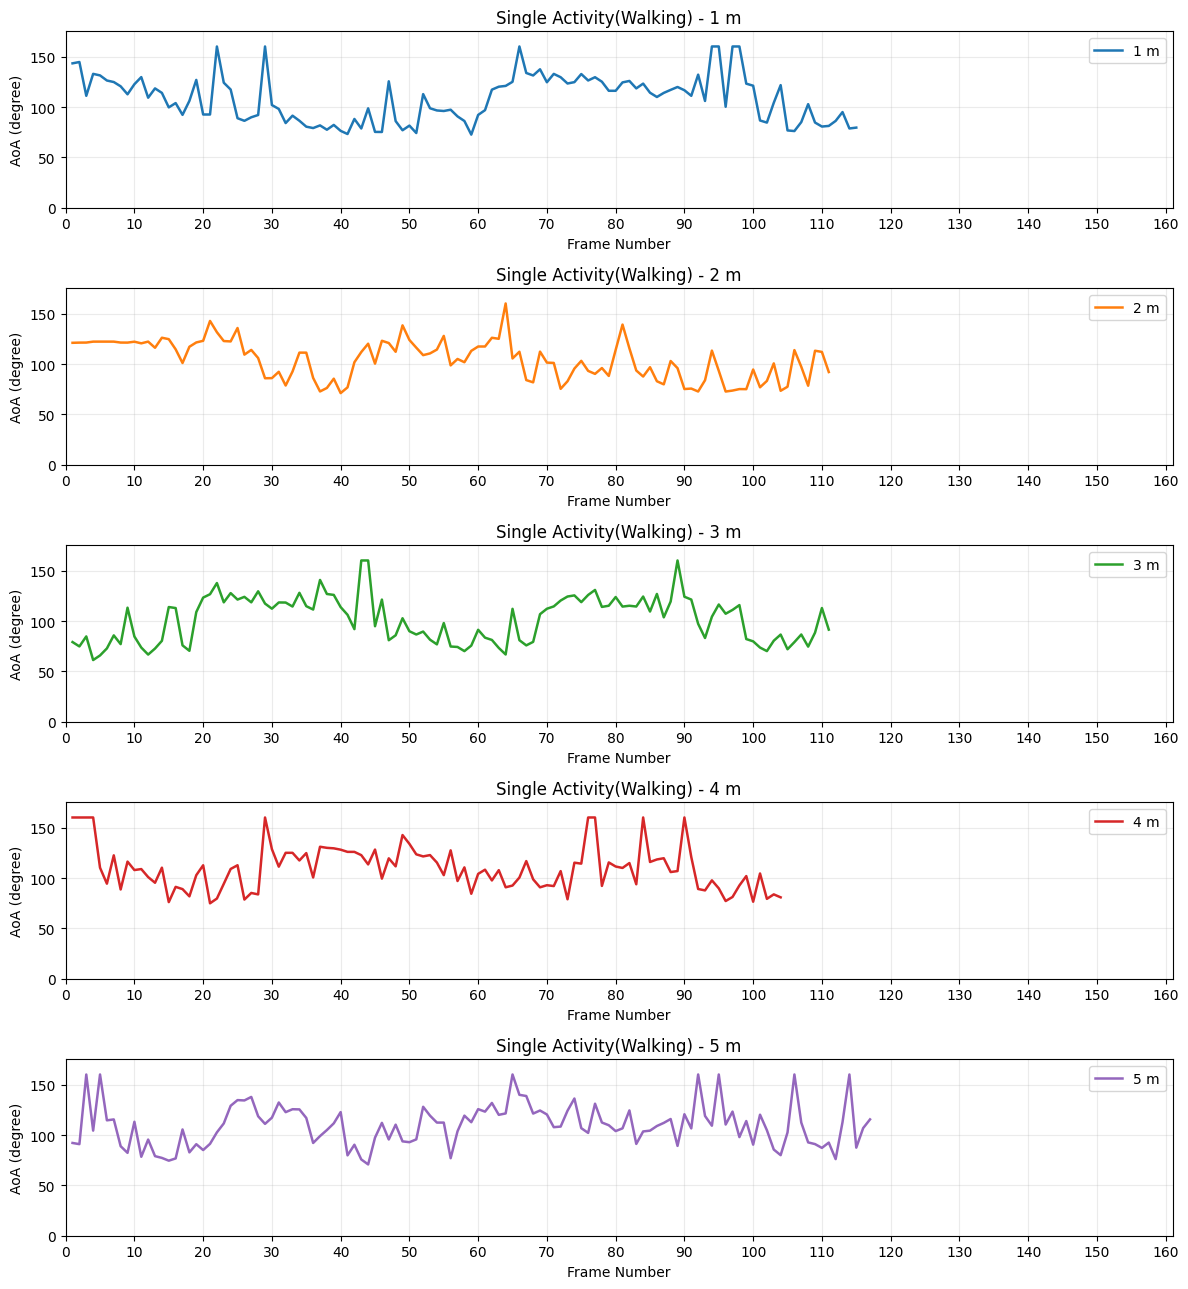

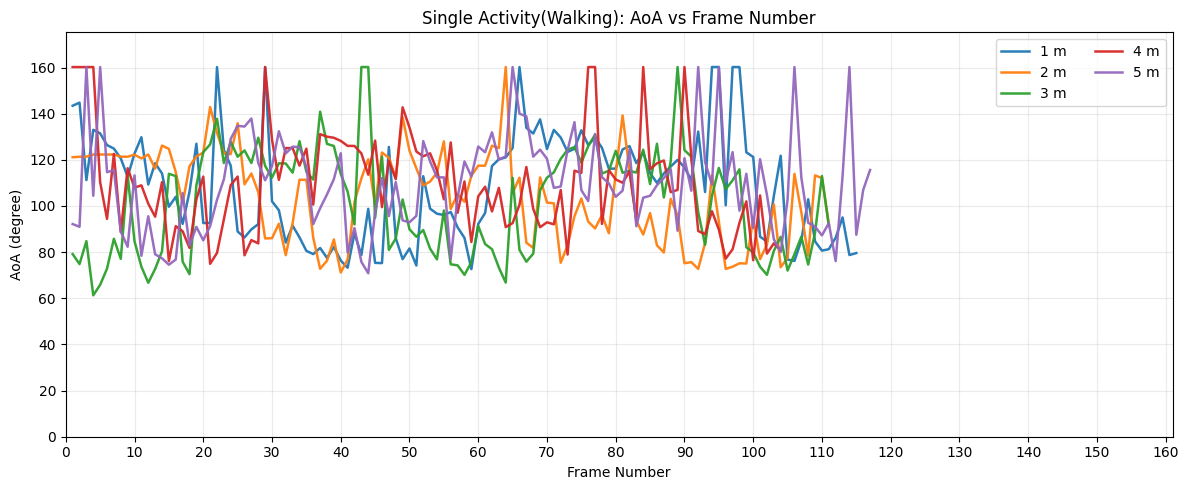

In [9]:
import re
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator


# Reuse objects from Cell 3.
if "single_root" not in globals() or single_root is None:
    raise RuntimeError("Run Cell 3 first.")
if "first_existing_dir" not in globals() or "first_existing_file" not in globals():
    raise RuntimeError("Run Cell 3 first.")

single_3d_root = first_existing_dir(single_root, ["3D data"])
if single_3d_root is None:
    raise FileNotFoundError("Single Activity 3D folder not found.")


def aoa_per_frame(csv_path):
    df = pd.read_csv(csv_path)
    cols = {str(c).strip().lower(): c for c in df.columns}
    if "frame_number" not in cols or "aoa" not in cols:
        return pd.DataFrame(columns=["frame_number", "aoa"])

    out = df[[cols["frame_number"], cols["aoa"]]].copy()
    out.columns = ["frame_number", "aoa"]
    out["frame_number"] = pd.to_numeric(out["frame_number"], errors="coerce")
    out["aoa"] = pd.to_numeric(out["aoa"], errors="coerce")
    out = out.dropna(subset=["frame_number", "aoa"])
    if out.empty:
        return out

    out["frame_number"] = out["frame_number"].astype(int)
    return out.groupby("frame_number", as_index=False)["aoa"].mean().sort_values("frame_number")


def session_sort_key(name):
    m = re.search(r"\d+(?:\.\d+)?", str(name))
    return float(m.group(0)) if m else float("inf")


# Build curves first so all plots can use the same axis origin/range.
activity_curves = {}
all_frame_max = 0
all_aoa_max = 0.0

for activity_dir in sorted([d for d in single_3d_root.iterdir() if d.is_dir()]):
    session_dirs = sorted(
        [d for d in activity_dir.iterdir() if d.is_dir()],
        key=lambda p: session_sort_key(p.name),
    )

    session_curves = []
    for i, session_dir in enumerate(session_dirs):
        csv_path = first_existing_file(session_dir, ["PointCloud_snr.csv"])
        if csv_path is None:
            continue

        curve = aoa_per_frame(csv_path)
        if curve.empty:
            continue

        color = plt.get_cmap("tab10")(i % 10)
        session_curves.append((session_dir.name, curve, color))

        all_frame_max = max(all_frame_max, int(curve["frame_number"].max()))
        all_aoa_max = max(all_aoa_max, float(curve["aoa"].max()))

    if session_curves:
        activity_curves[activity_dir.name] = session_curves

if not activity_curves:
    raise ValueError("No valid AoA data found to plot.")

# Same origin and range for all plots.
x_min, x_max = 0, all_frame_max
y_min, y_max = 0.0, all_aoa_max * 1.05

for activity_name, session_curves in activity_curves.items():
    # 1) Distance-wise plots for this activity in one figure.
    n = len(session_curves)
    fig, axes = plt.subplots(n, 1, figsize=(12, 2.6 * n), sharex=True, sharey=True)
    if n == 1:
        axes = [axes]

    for ax, (session_name, curve, color) in zip(axes, session_curves):
        ax.plot(curve["frame_number"], curve["aoa"], color=color, linewidth=1.8)
        ax.set_title(f"Single Activity({activity_name}) - {session_name}")
        ax.set_ylabel("AoA (degree)")
        ax.set_xlabel("Frame Number")
        ax.grid(alpha=0.25)
        ax.legend([session_name], loc="upper right")
        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_min, y_max)
        ax.xaxis.set_major_locator(MultipleLocator(10))
        ax.tick_params(axis="x", labelbottom=True)

    plt.tight_layout()
    plt.show()

    # 2) Combined graph for this activity (all distances together).
    plt.figure(figsize=(12, 5))
    for session_name, curve, color in session_curves:
        plt.plot(
            curve["frame_number"],
            curve["aoa"],
            label=session_name,
            color=color,
            linewidth=1.8,
            alpha=0.95,
        )

    plt.title(f"Single Activity({activity_name}): AoA vs Frame Number")
    plt.xlabel("Frame Number")
    plt.ylabel("AoA (degree)")
    plt.grid(alpha=0.25)
    plt.legend(ncol=2, loc="upper right")
    plt.xlim(x_min, x_max)
    plt.ylim(y_min, y_max)
    plt.gca().xaxis.set_major_locator(MultipleLocator(10))
    plt.tight_layout()
    plt.show()

## Modeling

- Range-Doppler branch: 3D CNN (spatial-temporal RD features)

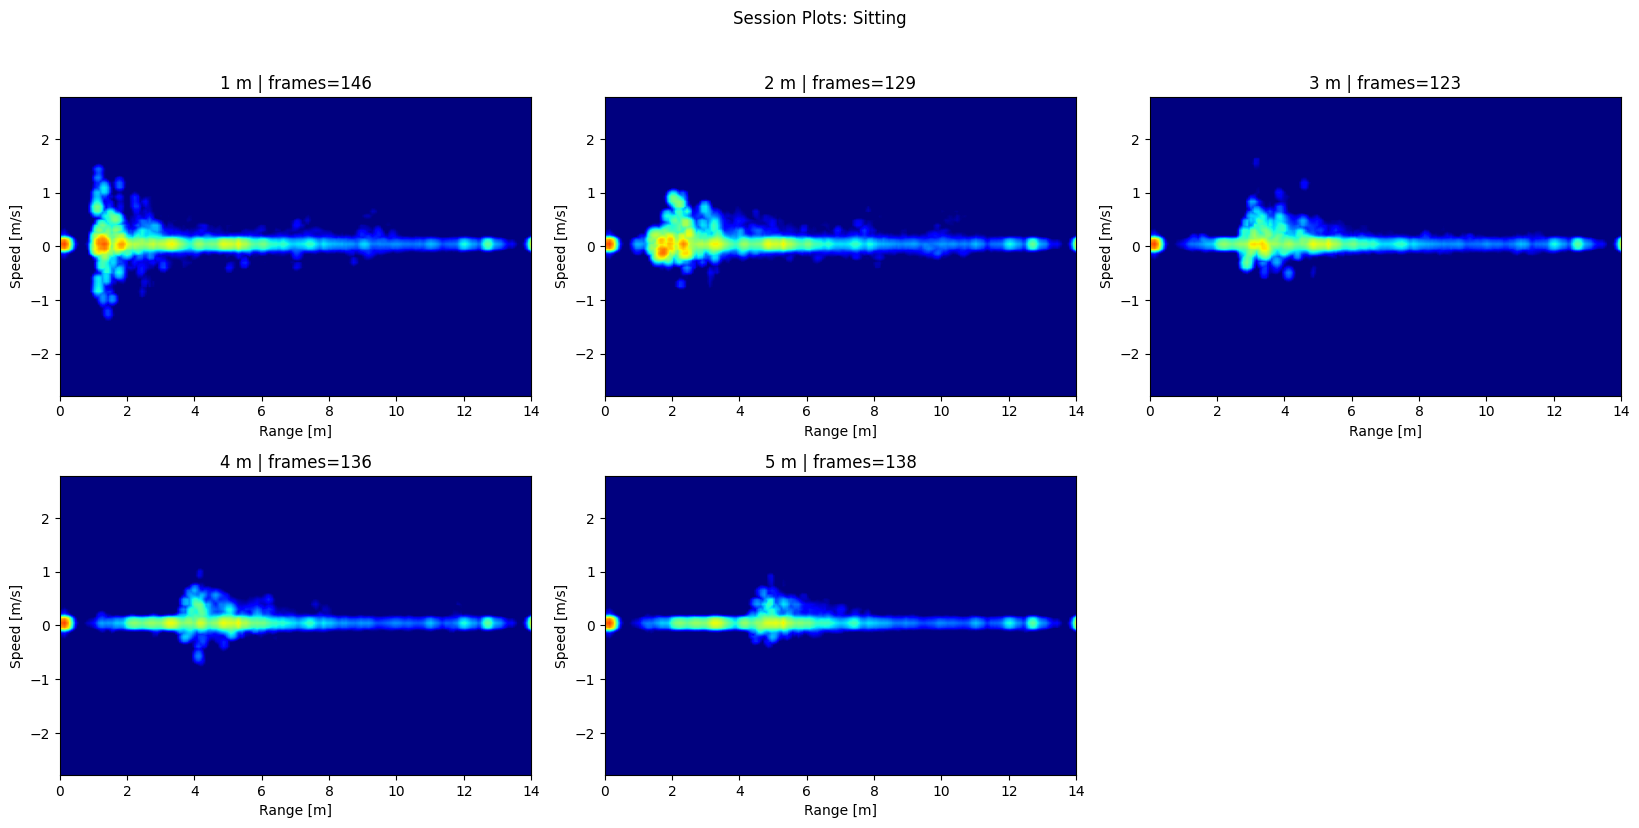

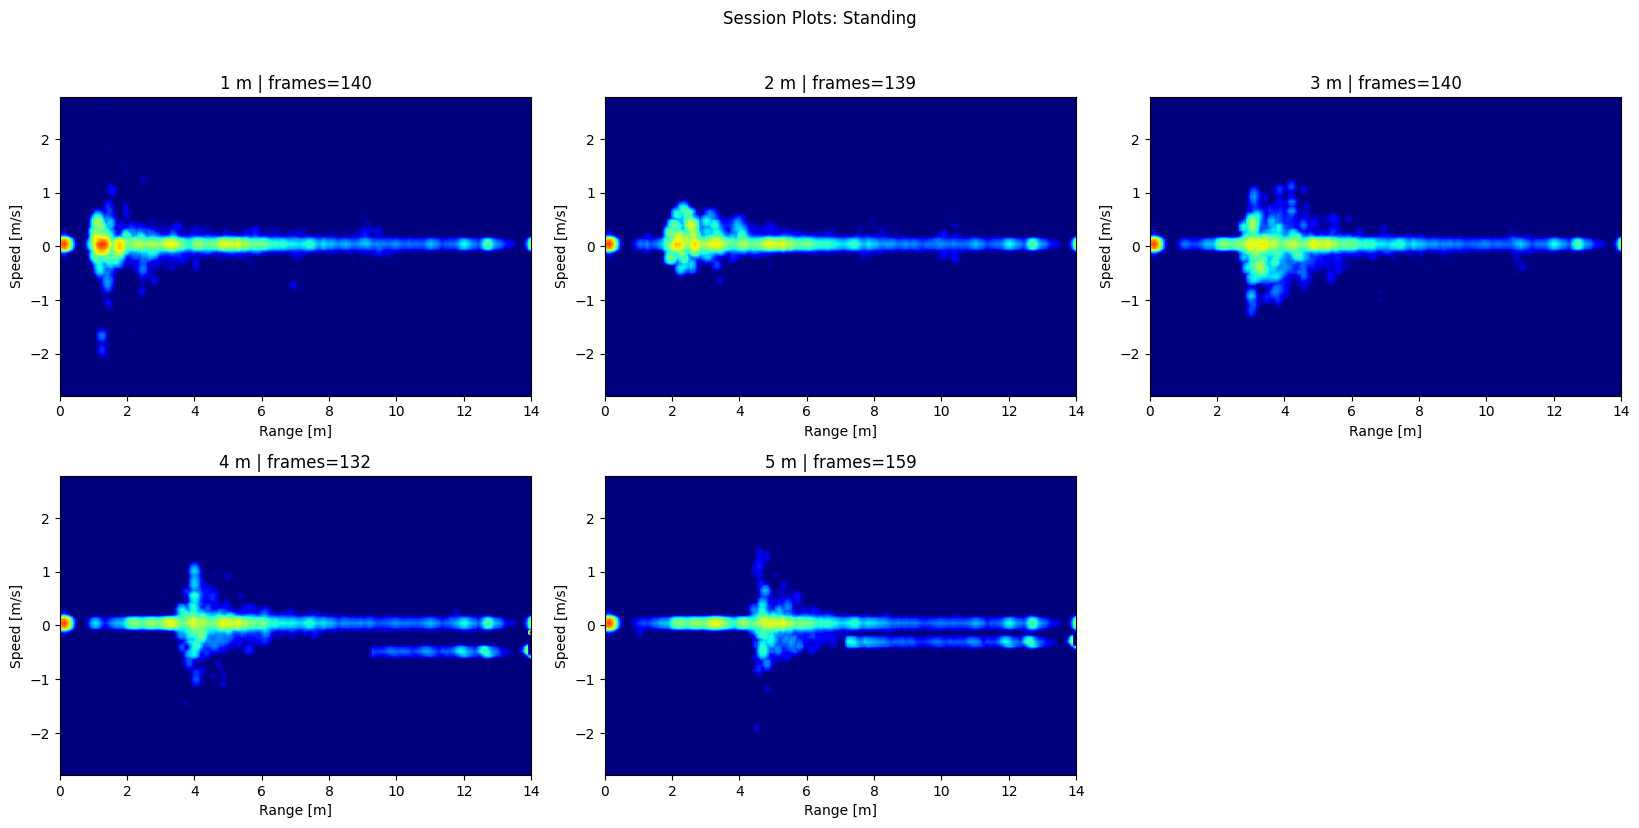

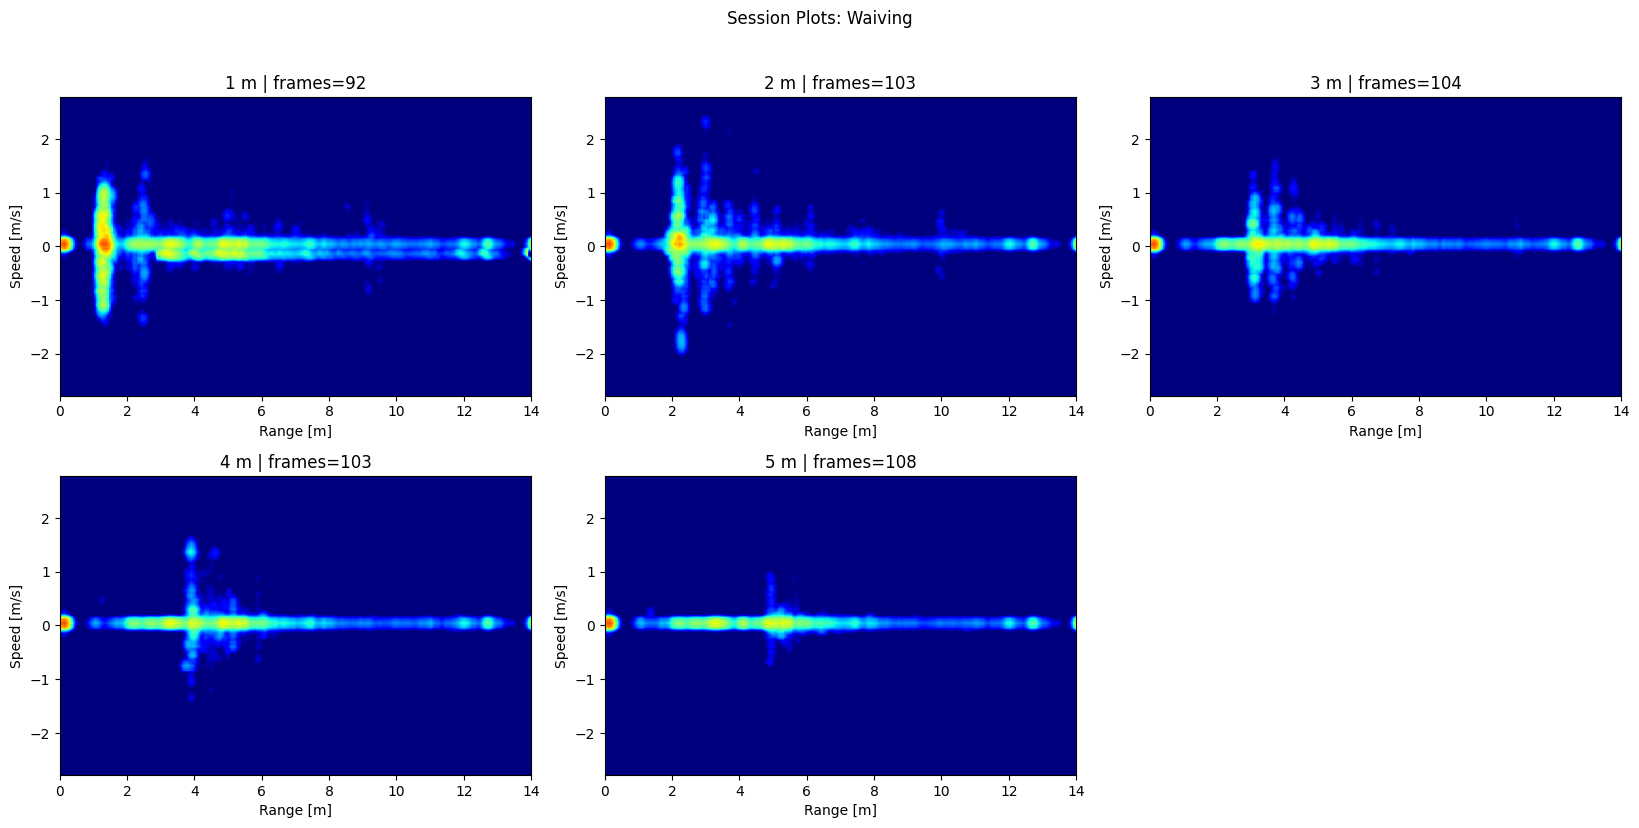

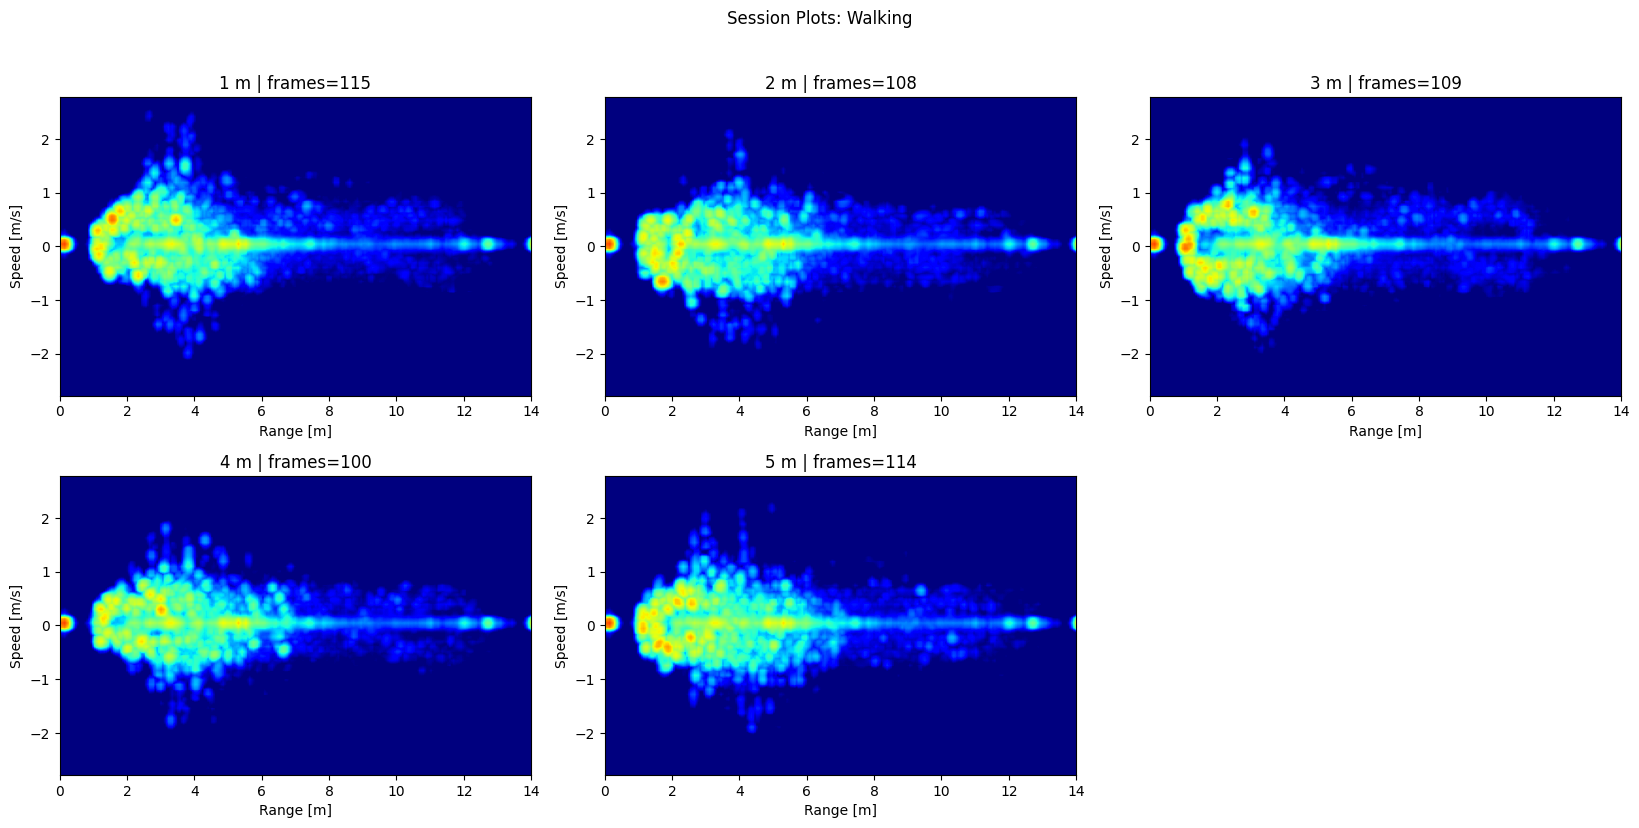

In [49]:
# session plots
import math

try:
    from scipy.ndimage import zoom as _zoom
except Exception:
    _zoom = None

if "single_root_local" not in globals() or single_root_local is None:
    raise RuntimeError("Run Cell 1 first.")

single_3d_root_viz = first_existing_dir(single_root_local, ["3D data", "3D", "3d data", "3d"])
if single_3d_root_viz is None:
    raise FileNotFoundError("Single Activity 3D folder not found.")

SESSION_PLOT_ACTIVITY = None  # "Sitting" for one activity, None for all activities
MAXIMUM_RANGE_M = 14.0
UNAMBIGUOUS_VELOCITY_MPS = 2.78
MIN_VALUE = 2048.0
MAX_VALUE = 4096.0
GRID_SIZE = 250


def _session_sort_key(name: str):
    m = re.search(r"\d+(?:\.\d+)?", str(name))
    return float(m.group(0)) if m else float("inf")


def _read_rd_csv_any_format(csv_path: Path) -> pd.DataFrame:
    df = pd.read_csv(csv_path)
    needed = ["frame_number", "range_bin", "doppler_bin", "signal_strength"]

    if all(c in df.columns for c in needed):
        out = df[needed].copy()
    else:
        raw = pd.read_csv(csv_path, header=None)
        if raw.shape[1] >= 5:
            raw = raw.iloc[:, :5].copy()
            raw.columns = ["timestamp", "frame_number", "range_bin", "doppler_bin", "signal_strength"]
            out = raw[needed].copy()
        elif raw.shape[1] == 4:
            raw.columns = needed
            out = raw[needed].copy()
        else:
            raise ValueError(f"Unexpected CSV format: {csv_path}")

    out[needed] = out[needed].apply(pd.to_numeric, errors="coerce")
    out = out.dropna(subset=needed)
    out["frame_number"] = out["frame_number"].astype(int)
    out["range_bin"] = out["range_bin"].astype(int)
    out["doppler_bin"] = out["doppler_bin"].astype(int)
    return out


def _build_heatmaps(df: pd.DataFrame):
    heatmaps = []
    frame_numbers = []

    max_range_bin = int(df["range_bin"].max())
    max_doppler_bin = int(df["doppler_bin"].max())
    h = max_range_bin + 1
    w = max_doppler_bin + 1

    for frame_num, part in df.groupby("frame_number", sort=True):
        mat = np.zeros((h, w), dtype=np.float32)
        rb = part["range_bin"].to_numpy(dtype=np.int64)
        db = part["doppler_bin"].to_numpy(dtype=np.int64)
        sig = part["signal_strength"].to_numpy(dtype=np.float32)

        valid = (rb >= 0) & (rb < h) & (db >= 0) & (db < w)
        rb = rb[valid]
        db = db[valid]
        sig = sig[valid]

        if len(sig) > 0:
            mat[rb, db] = sig

        heatmaps.append(mat)
        frame_numbers.append(int(frame_num))

    return heatmaps, frame_numbers


def _filter_anomalous_frames(heatmaps, frame_numbers):
    if len(heatmaps) < 5:
        return heatmaps, frame_numbers

    means = np.array([h.mean() for h in heatmaps], dtype=np.float32)
    stds = np.array([h.std() for h in heatmaps], dtype=np.float32)
    peaks = np.array([h.max() for h in heatmaps], dtype=np.float32)
    sat_counts = np.array([(h > 60000).sum() for h in heatmaps], dtype=np.float32)

    def robust_abs_z(values):
        med = np.median(values)
        mad = np.median(np.abs(values - med))
        if mad < 1e-9:
            return np.zeros_like(values)
        return np.abs((values - med) / (1.4826 * mad))

    z_mean = robust_abs_z(means)
    z_std = robust_abs_z(stds)
    z_peak = robust_abs_z(peaks)

    mask = (
        (sat_counts > 0)
        | (peaks > 10000)
        | (stds > 2000)
        | ((z_peak > 12.0) & (z_std > 12.0) & (z_mean > 12.0))
    )

    kept_heatmaps = [h for i, h in enumerate(heatmaps) if not mask[i]]
    kept_frames = [f for i, f in enumerate(frame_numbers) if not mask[i]]
    return kept_heatmaps, kept_frames


def _resize_2d(arr: np.ndarray, out_h: int, out_w: int) -> np.ndarray:
    if _zoom is not None:
        return _zoom(arr, (out_h / arr.shape[0], out_w / arr.shape[1]), order=1)

    rep_h = int(np.ceil(out_h / arr.shape[0]))
    rep_w = int(np.ceil(out_w / arr.shape[1]))
    up = np.repeat(np.repeat(arr, rep_h, axis=0), rep_w, axis=1)
    return up[:out_h, :out_w]


def _preprocess_frame_for_display(frame: np.ndarray) -> np.ndarray:
    shifted = np.fft.fftshift(frame, axes=1)
    out_h = max(GRID_SIZE, shifted.shape[0])
    out_w = max(GRID_SIZE, shifted.shape[1])
    interp = _resize_2d(shifted, out_h, out_w).astype(np.float32)

    denom = max(MAX_VALUE - MIN_VALUE, 1e-9)
    norm = (interp - MIN_VALUE) / denom
    return np.clip(norm, 0.0, 1.0)


def _build_session_pattern(heatmaps):
    if not heatmaps:
        return np.zeros((GRID_SIZE, GRID_SIZE), dtype=np.float32)

    base_shape = heatmaps[0].shape
    valid_frames = [h for h in heatmaps if h.shape == base_shape]
    if not valid_frames:
        valid_frames = heatmaps

    processed = [_preprocess_frame_for_display(h) for h in valid_frames]
    return np.max(np.stack(processed, axis=0), axis=0)


if SESSION_PLOT_ACTIVITY is None:
    activity_dirs = sorted([d for d in single_3d_root_viz.iterdir() if d.is_dir()])
else:
    activity_dir = single_3d_root_viz / SESSION_PLOT_ACTIVITY
    if not activity_dir.exists():
        available = sorted([d.name for d in single_3d_root_viz.iterdir() if d.is_dir()])
        raise ValueError(f"Activity '{SESSION_PLOT_ACTIVITY}' not found. Available: {available}")
    activity_dirs = [activity_dir]

if not activity_dirs:
    raise ValueError("No activity folders found under Single Activity/3D data")

for activity_dir in activity_dirs:
    session_dirs = sorted(
        [d for d in activity_dir.iterdir() if d.is_dir() and (d / "range_doppler.csv").exists()],
        key=lambda p: _session_sort_key(p.name),
    )
    if not session_dirs:
        continue

    plots = []
    for session_dir in session_dirs:
        rd_csv = session_dir / "range_doppler.csv"
        rd_df = _read_rd_csv_any_format(rd_csv)
        heatmaps, frame_numbers = _build_heatmaps(rd_df)
        heatmaps, frame_numbers = _filter_anomalous_frames(heatmaps, frame_numbers)
        if not heatmaps:
            continue

        pattern = _build_session_pattern(heatmaps)
        plots.append((session_dir.name, pattern, len(frame_numbers)))

    if not plots:
        continue

    n = len(plots)
    cols_n = min(3, n)
    rows_n = int(np.ceil(n / cols_n))
    fig, axes = plt.subplots(rows_n, cols_n, figsize=(5.5 * cols_n, 4.2 * rows_n), squeeze=False)

    for idx, (session_name, pattern, frame_count) in enumerate(plots):
        r = idx // cols_n
        c = idx % cols_n
        ax = axes[r][c]
        ax.imshow(
            pattern.T,
            origin="lower",
            aspect="auto",
            cmap="jet",
            vmin=0.0,
            vmax=1.0,
            extent=[0.0, MAXIMUM_RANGE_M, -UNAMBIGUOUS_VELOCITY_MPS, UNAMBIGUOUS_VELOCITY_MPS],
        )
        ax.set_title(f"{session_name} | frames={frame_count}")
        ax.set_xlabel("Range [m]")
        ax.set_ylabel("Speed [m/s]")

    for idx in range(n, rows_n * cols_n):
        r = idx // cols_n
        c = idx % cols_n
        axes[r][c].axis("off")

    fig.suptitle(f"Session Plots: {activity_dir.name}")
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()